In [1]:
import numpy as np
import xarray as xr
import os

from scipy.stats import linregress, pearsonr
import random

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

import pandas as pd
import seaborn as sns

import warnings
from mezcal_tools import *

warnings.filterwarnings("ignore", category=UserWarning)

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# -------------------------------------------------------------------------
# Assessing the Skill of SST–AMOC Reconstructions: Individual Models vs Multi-Model Approach
#
# This notebook performs the following tasks:
#
# 1. Computes multi-model SST–AMOC regression patterns using random subsampling 
#    (10 years from each model), and compares these patterns to assess sensitivity 
#    to year selection.
#
# 2. Computes SST–AMOC regression patterns and AMOC reconstructions for:
#    - Each individual model
#    - Multi-model ensemble
#
# 3. Evaluates reconstruction skill by computing RMSE between the true AMOC 
#    and reconstructed AMOC from:
#    - The same model
#    - Other individual models
#    - Multi-model regression patterns (with and without subsampling)
#
# 4. Visualizes the RMSE comparison in a format analogous to Fig. 3 of 
#    Parsons et al. (2021): https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2020EA001467
# -------------------------------------------------------------------------

In [3]:
scenario = 'piControl'
running_mean_window = 20

lat_min = 0
lat_max = 90

lon_min = -100
lon_max = 15

PATH_SST = '../data/SST/' + scenario + '/'
PATH_AMOC = '../data/AMOC/' + scenario + '/'
PATH_saved_regressions = '../data/SST_AMOC_saved_regressions/'
PATH_saved_cross_regressions = '../data/SST_AMOC_cross_regressions_for_every_model/'

model_names = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'CESM2-WACCM', 'CESM2', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1-HR',
               'CNRM-CM6-1', 'CNRM-ESM2-1', 'CanESM5-CanOE', 'CanESM5', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 
               'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 
               'MRI-ESM2-0', 'NorESM2-LM', 'NorESM2-MM', 'UKESM1-0-LL']


amoc_institution_names = ['CSIRO-ARCCSS', 'CSIRO', 'NCAR', 'NCAR', 'CMCC', 'CMCC', 'CNRM-CERFACS', 
                         'CNRM-CERFACS', 'CNRM-CERFACS', 'CCCma', 'CCCma', 'NOAA-GFDL', 'NOAA-GFDL', 'NASA-GISS', 
                         'MOHC', 'MOHC', 'IPSL', 'MIROC', 'DKRZ', 'MPI-M', 
                         'MRI', 'NCC', 'NCC', 'MOHC']
                         


ens_members_appendices  = ['r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f2', 'r1i1p1f2', 'r1i1p2f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 
                           'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f1', 'r1i1p1f2']

# Test how different sub-sampling effects multi-model regression pattern

In [4]:
seed_list = [0, 1, 2, 3, 4]
regression_patterns = {}

for seed in seed_list:
    tag = f'random10_seed{seed}'
    print(f"\n=== Running seed {seed} ===\n")
    
    f, _, _, _, _ = compute_regression_from_random_years(
        model_names=model_names,
        amoc_institution_names=amoc_institution_names,
        ens_members_appendices=ens_members_appendices,
        scenario='piControl',
        PATH_SST=PATH_SST,
        PATH_AMOC=PATH_AMOC,
        lat_min=lat_min,
        lat_max=lat_max,
        lon_min=lon_min,
        lon_max=lon_max,
        running_mean_window=running_mean_window,
        tag=tag,
        PATH_saved_regressions=PATH_saved_regressions,
        plot=False,
        random_seed=seed
    )
    
    regression_patterns[seed] = f



=== Running seed 0 ===

Processing: ACCESS-CM2
Processing: ACCESS-ESM1-5
Processing: CESM2-WACCM
Processing: CESM2
Processing: CMCC-CM2-SR5
Processing: CMCC-ESM2
Processing: CNRM-CM6-1-HR
Processing: CNRM-CM6-1
Processing: CNRM-ESM2-1
Processing: CanESM5-CanOE
Processing: CanESM5
Processing: GFDL-CM4
Processing: GFDL-ESM4
Processing: GISS-E2-1-G
Processing: HadGEM3-GC31-LL
Processing: HadGEM3-GC31-MM
Processing: IPSL-CM6A-LR
Processing: MIROC6
Processing: MPI-ESM1-2-HR
Processing: MPI-ESM1-2-LR
Processing: MRI-ESM2-0
Processing: NorESM2-LM
Processing: NorESM2-MM
Processing: UKESM1-0-LL

=== Running seed 1 ===

Processing: ACCESS-CM2
Processing: ACCESS-ESM1-5
Processing: CESM2-WACCM
Processing: CESM2
Processing: CMCC-CM2-SR5
Processing: CMCC-ESM2
Processing: CNRM-CM6-1-HR
Processing: CNRM-CM6-1
Processing: CNRM-ESM2-1
Processing: CanESM5-CanOE
Processing: CanESM5
Processing: GFDL-CM4
Processing: GFDL-ESM4
Processing: GISS-E2-1-G
Processing: HadGEM3-GC31-LL
Processing: HadGEM3-GC31-MM
P

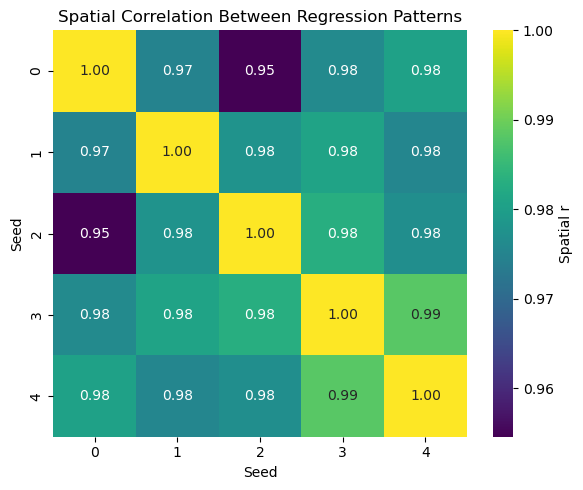

In [5]:
def spatial_correlation(f1, f2):
    return pearsonr(f1.flatten(), f2.flatten())[0]

# Create matrix of correlations
n = len(seed_list)
r_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        f1 = regression_patterns[seed_list[i]]
        f2 = regression_patterns[seed_list[j]]
        r_matrix[i, j] = spatial_correlation(f1, f2)


df_r = pd.DataFrame(r_matrix, index=seed_list, columns=seed_list)
plt.figure(figsize=(6, 5))
sns.heatmap(df_r, annot=True, cmap='viridis', fmt=".2f", cbar_kws={"label": "Spatial r"})
plt.title("Spatial Correlation Between Regression Patterns")
plt.xlabel("Seed")
plt.ylabel("Seed")
plt.tight_layout()
plt.show()


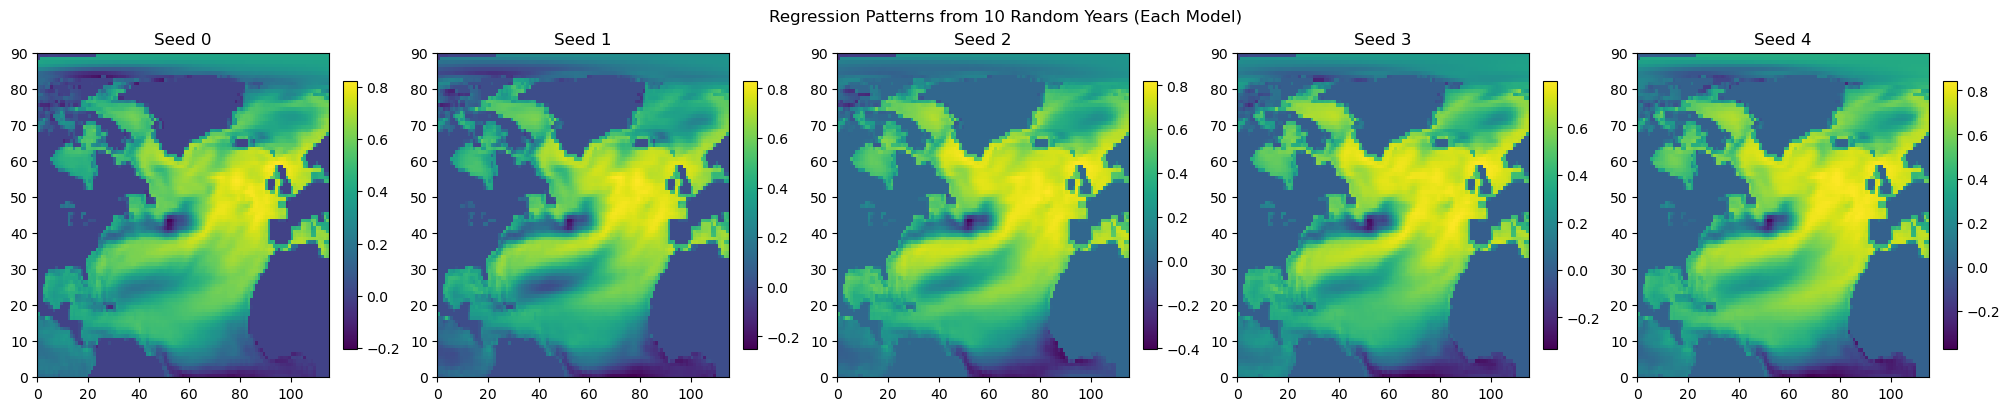

In [6]:
ncols = len(seed_list)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4), constrained_layout=True)

filename_sst = PATH_SST + 'tos_Omon_' + model_names[-1] + '_' + scenario + '_' + ens_members_appendices[-1] + '.nc'
sst_test = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))

ny, nx = sst_test.shape[1], sst_test.shape[2]  # assuming sst_used1 is (year, lat, lon)

for idx, seed in enumerate(seed_list):
    ax = axes[idx]
    f_map = regression_patterns[seed].reshape((ny, nx))  # replace ny, nx with actual shape if needed
    im = ax.pcolormesh(f_map, shading='auto')
    ax.set_title(f"Seed {seed}")
    fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046)

plt.suptitle("Regression Patterns from 10 Random Years (Each Model)")
plt.show()


# Multi-model regression (from subsampled models)

Processing: ACCESS-CM2
Processing: ACCESS-ESM1-5
Processing: CESM2-WACCM
Processing: CESM2
Processing: CMCC-CM2-SR5
Processing: CMCC-ESM2
Processing: CNRM-CM6-1-HR
Processing: CNRM-CM6-1
Processing: CNRM-ESM2-1
Processing: CanESM5-CanOE
Processing: CanESM5
Processing: GFDL-CM4
Processing: GFDL-ESM4
Processing: GISS-E2-1-G
Processing: HadGEM3-GC31-LL
Processing: HadGEM3-GC31-MM
Processing: IPSL-CM6A-LR
Processing: MIROC6
Processing: MPI-ESM1-2-HR
Processing: MPI-ESM1-2-LR
Processing: MRI-ESM2-0
Processing: NorESM2-LM
Processing: NorESM2-MM
Processing: UKESM1-0-LL
Saved to ../data/SST_AMOC_saved_regressions/run1_seed42_240yrs.nc


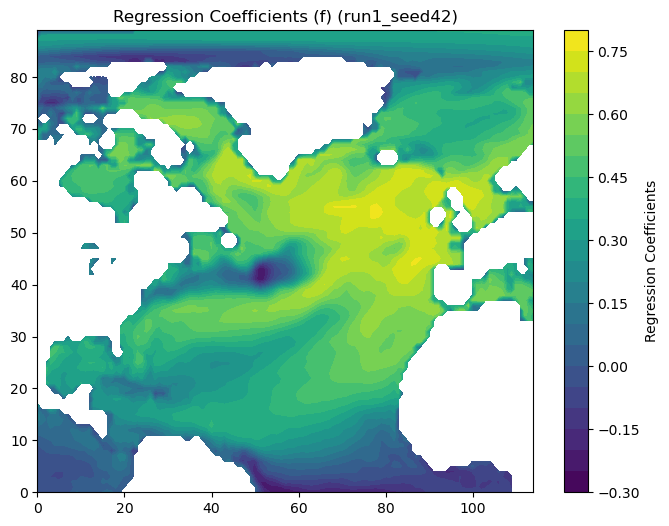

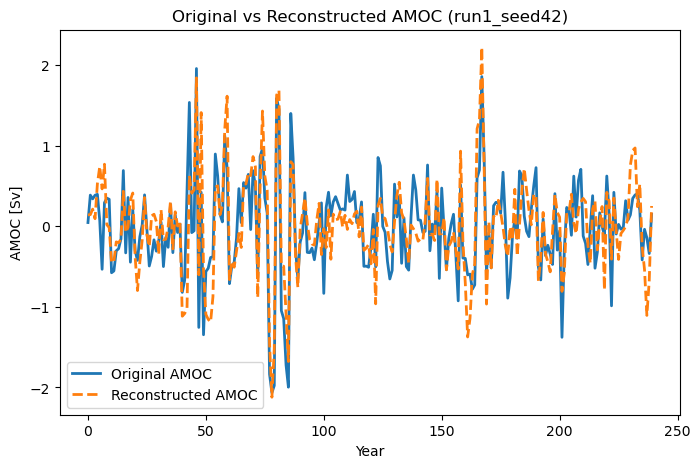

In [7]:
f_mm_subsampled, amoc_recon1, amoc_true1, sst_used1, amoc_used1 = compute_regression_from_random_years(
    model_names=model_names,
    amoc_institution_names=amoc_institution_names,
    ens_members_appendices=ens_members_appendices,
    scenario='piControl',
    PATH_SST=PATH_SST,
    PATH_AMOC=PATH_AMOC,
    lat_min=0, lat_max=90,
    lon_min=-100, lon_max=15,
    running_mean_window=20,
    tag='run1_seed42',
    PATH_saved_regressions=PATH_saved_regressions,
    plot=True,
    random_seed=42
)

# Multi-model regression (full models' timeseries)

In [8]:
sst_multiple_models = {}
amoc_multiple_models = {}
for i, model in enumerate(model_names):

    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'

    print(model)

    sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
    sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
    sst_mean = sst_time_series.mean('year')
    sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

    sst = sst_smoothed

    sst_normalized = prepare_and_normalize_sst(sst)

    # Get spatial grid dimensions for the North Atlantic region
    ny = sst.mean('year').shape[0]
    nx = sst.mean('year').shape[1]

    if model == 'IPSL-CM6A-LR':
        amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
    else:
        amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
        
    amoc_mean = amoc_time_series.mean('year')
    amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
    amoc_smoothed['year'] = xr.DataArray(np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1), dims = 'year')

    amoc = amoc_smoothed

    sst_multiple_models[i] = sst 
    amoc_multiple_models[i] = amoc

ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


Saved to ../data/SST_AMOC_saved_regressions/multimodel_5544yrs.nc


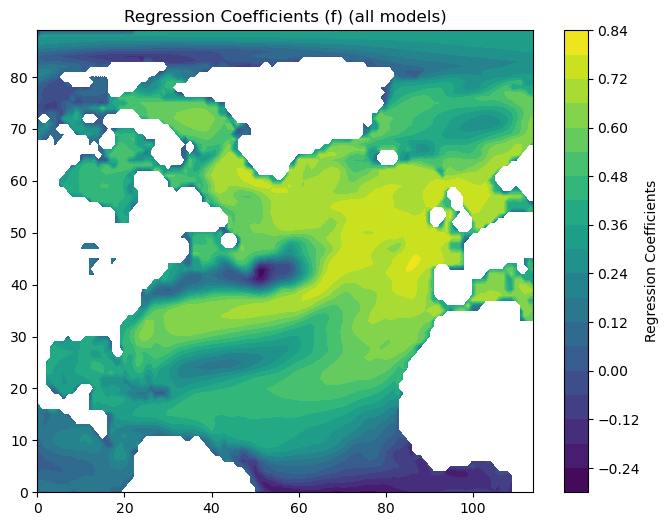

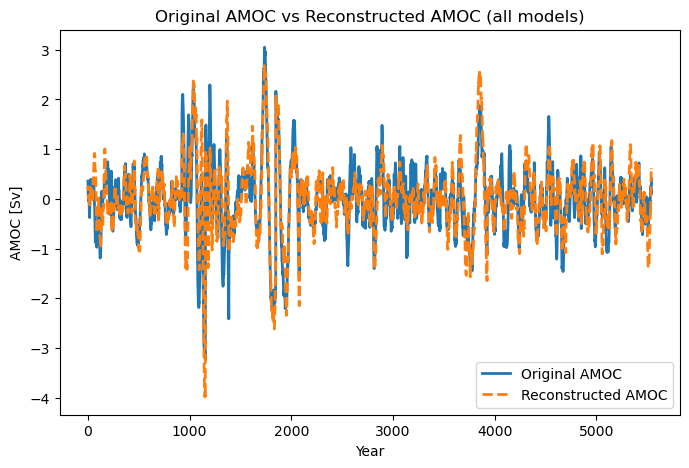

In [9]:
sst_matrices = [sst_multiple_models[key] for key in sst_multiple_models]
sst_all = np.vstack(sst_matrices)

amoc_matrices = [amoc_multiple_models[key] for key in amoc_multiple_models]
amoc_all = np.hstack(amoc_matrices).T

sst_all = xr.DataArray(
    sst_all,
    dims=["year", "lat", "lon"],
    coords={"year": np.arange(sst_all.shape[0]), "lat": sst.lat.values, "lon": sst.lon.values},
    name="sst"
)

amoc_all = xr.DataArray(
    amoc_all,
    dims=["year"],
    coords={"year": np.arange(amoc_all.shape[0])},
    name="amoc"
)


# Prepare and normalize data    
sst_normalized = prepare_and_normalize_sst(sst_all)
amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc_all)

# Train regression and reconstruct AMOC
f_mm_all, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

years = sst_all.year.values
save_regression_map_sst_amoc_to_file(f_mm_all, ny, nx, years, sst_smoothed, sst_normalized, amoc_normalized, amoc_std, amoc_reconstructed, 'multimodel', PATH_saved_regressions, smoothing_period = running_mean_window)

# Plot regression coefficients
plot_regression_coefficients(f_mm_all, ny, nx, f"Regression Coefficients (f) (all models)",model_names)

# Plot AMOC comparison
years = sst_all.year.values
plot_amoc_comparison(amoc, amoc_reconstructed, years, 
                     f"Original AMOC vs Reconstructed AMOC (all models)", smoothing_period = running_mean_window)


# Compute and save SST-based AMOC reconstructions for each model 

ACCESS-CM2
Saved to ../data/SST_AMOC_saved_regressions/ACCESS-CM2_231yrs.nc


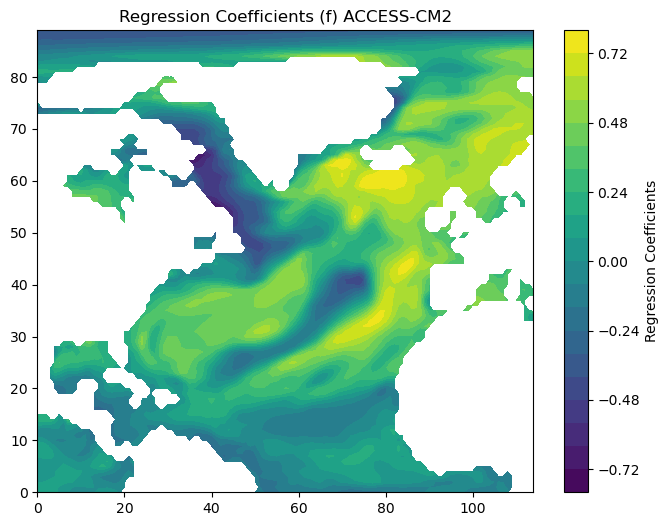

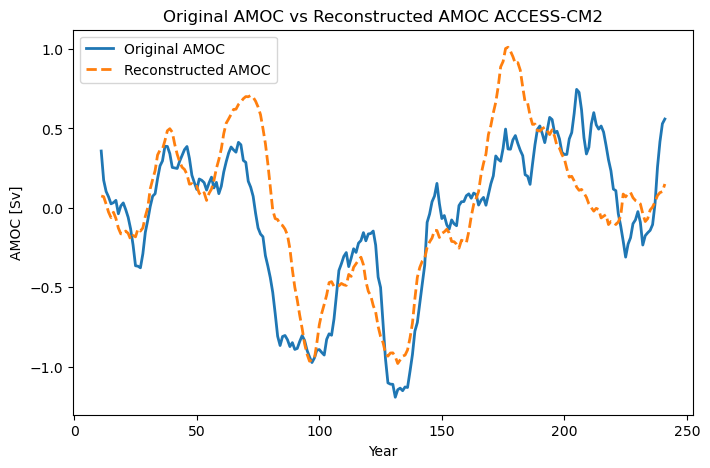

f range: -0.7406 to 0.7991
AMOC range: -1.1921 to 0.7459
Reconstructed AMOC range: -0.9799 to 1.0112
ACCESS-ESM1-5
Saved to ../data/SST_AMOC_saved_regressions/ACCESS-ESM1-5_231yrs.nc


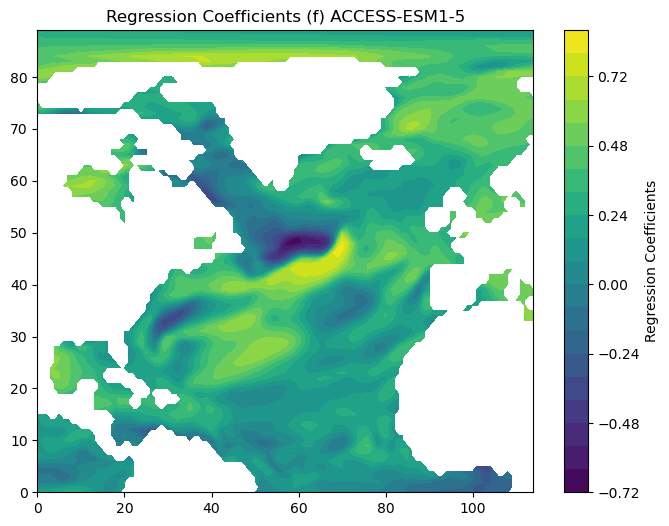

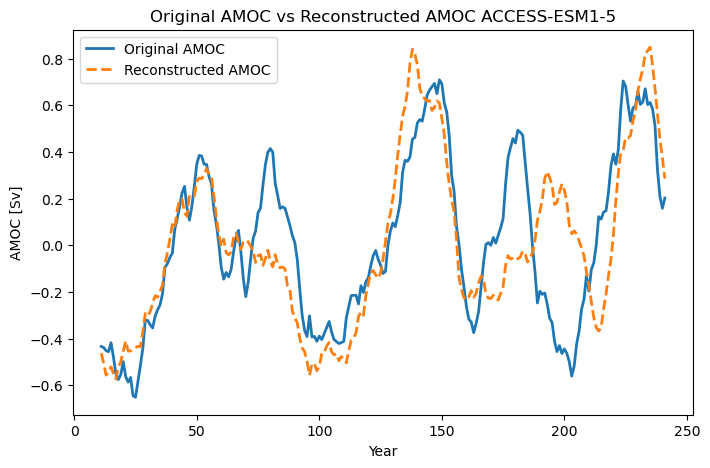

f range: -0.6921 to 0.8232
AMOC range: -0.6515 to 0.7097
Reconstructed AMOC range: -0.5733 to 0.8492
CESM2-WACCM
Saved to ../data/SST_AMOC_saved_regressions/CESM2-WACCM_231yrs.nc


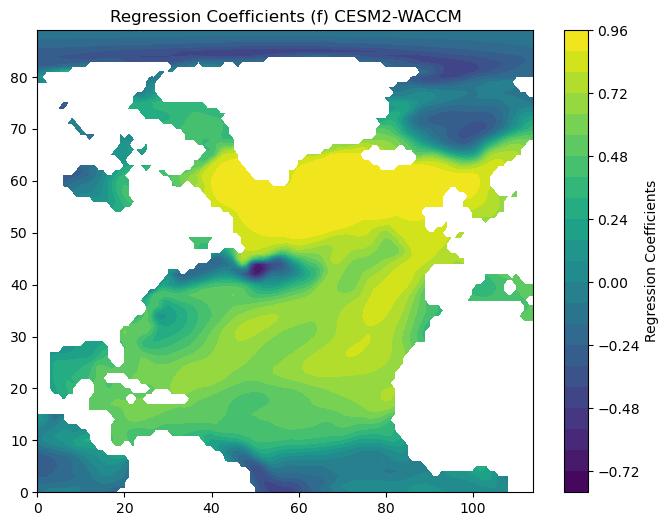

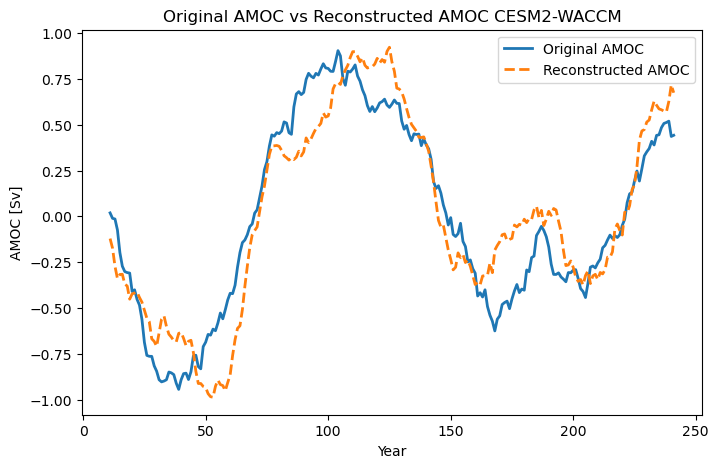

f range: -0.7263 to 0.9499
AMOC range: -0.9446 to 0.9048
Reconstructed AMOC range: -0.9874 to 0.9236
CESM2
Saved to ../data/SST_AMOC_saved_regressions/CESM2_231yrs.nc


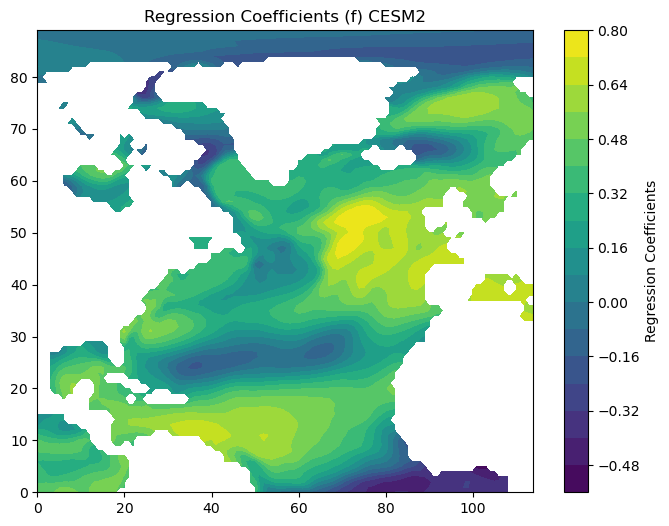

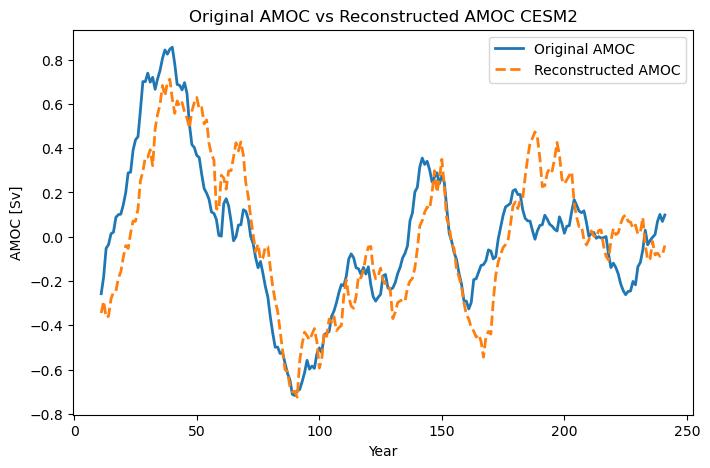

f range: -0.5240 to 0.7781
AMOC range: -0.7176 to 0.8561
Reconstructed AMOC range: -0.7252 to 0.7121
CMCC-CM2-SR5
Saved to ../data/SST_AMOC_saved_regressions/CMCC-CM2-SR5_231yrs.nc


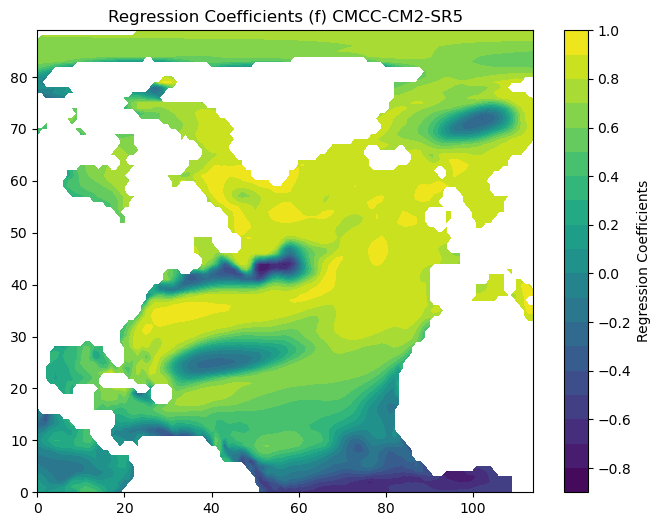

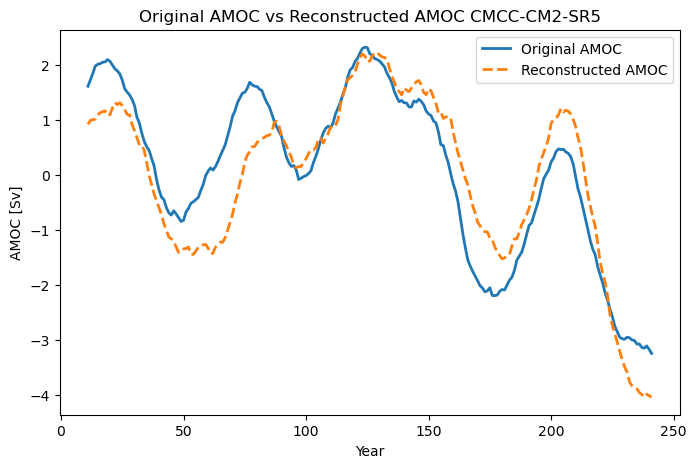

f range: -0.8311 to 0.9422
AMOC range: -3.2411 to 2.3273
Reconstructed AMOC range: -4.0376 to 2.2317
CMCC-ESM2
Saved to ../data/SST_AMOC_saved_regressions/CMCC-ESM2_231yrs.nc


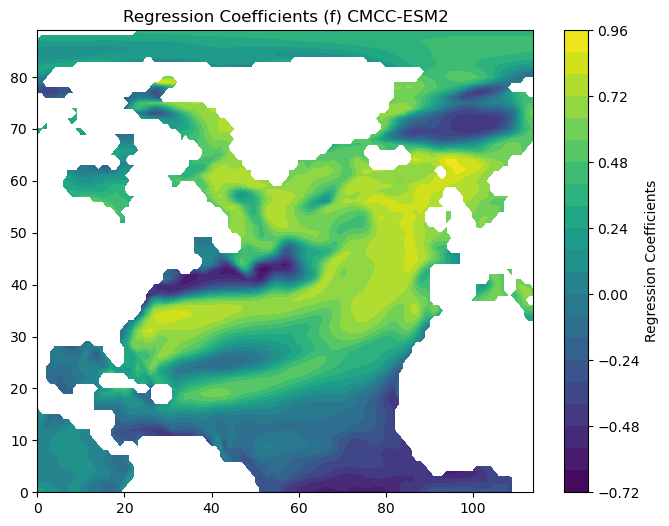

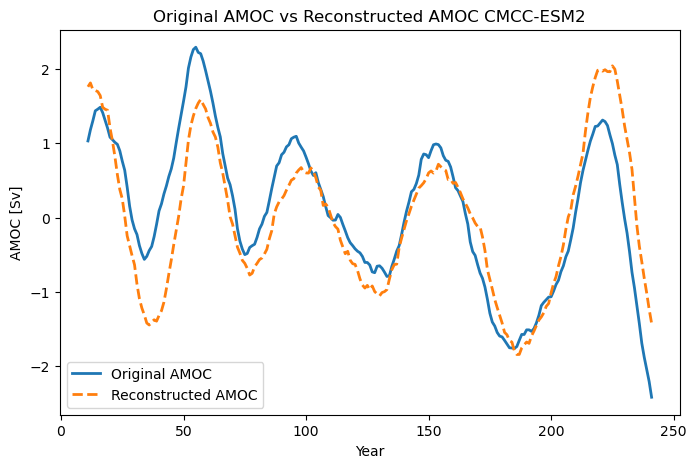

f range: -0.6809 to 0.9126
AMOC range: -2.4157 to 2.2937
Reconstructed AMOC range: -1.8410 to 2.0432
CNRM-CM6-1-HR
Saved to ../data/SST_AMOC_saved_regressions/CNRM-CM6-1-HR_231yrs.nc


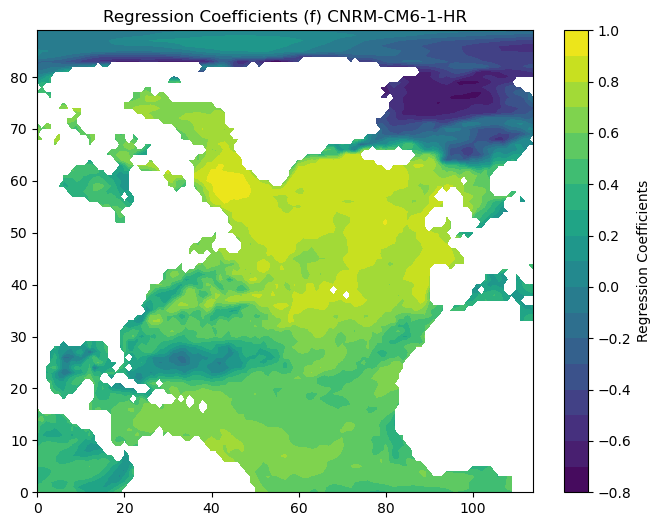

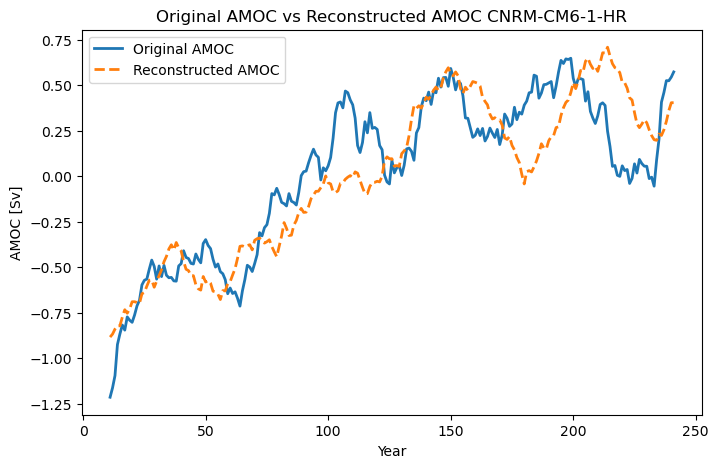

f range: -0.7713 to 0.9287
AMOC range: -1.2146 to 0.6484
Reconstructed AMOC range: -0.8840 to 0.7090
CNRM-CM6-1
Saved to ../data/SST_AMOC_saved_regressions/CNRM-CM6-1_231yrs.nc


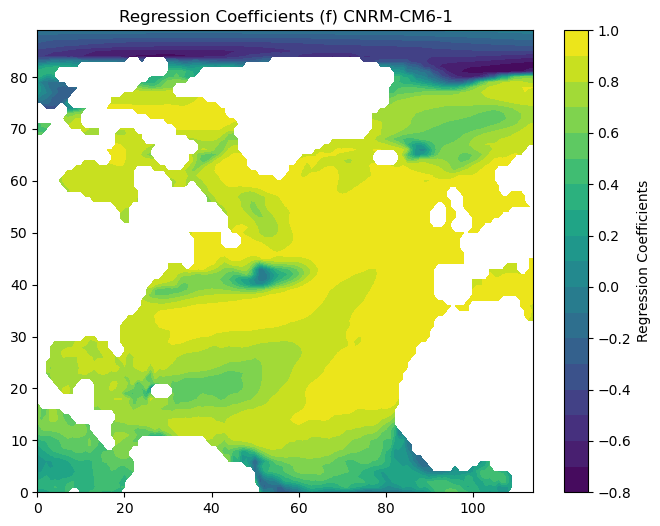

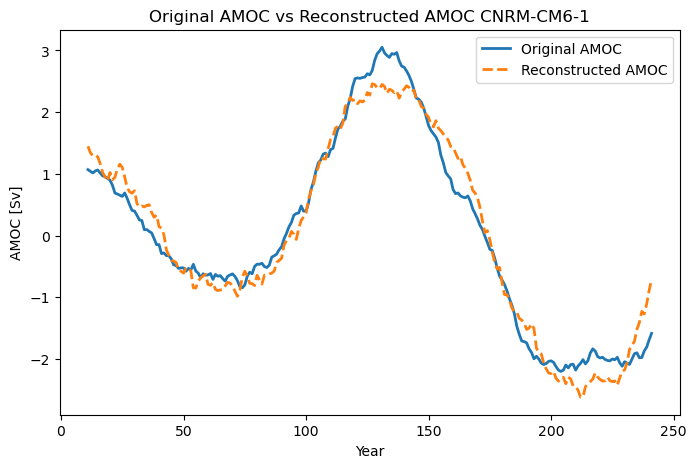

f range: -0.7960 to 0.9859
AMOC range: -2.2007 to 3.0513
Reconstructed AMOC range: -2.6189 to 2.4589
CNRM-ESM2-1
Saved to ../data/SST_AMOC_saved_regressions/CNRM-ESM2-1_231yrs.nc


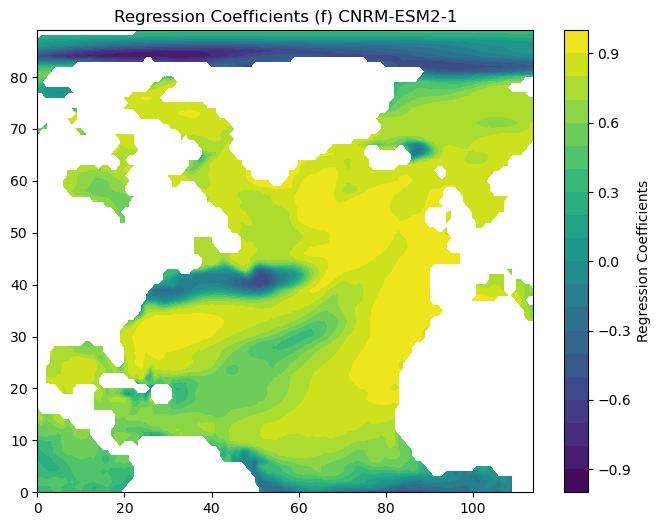

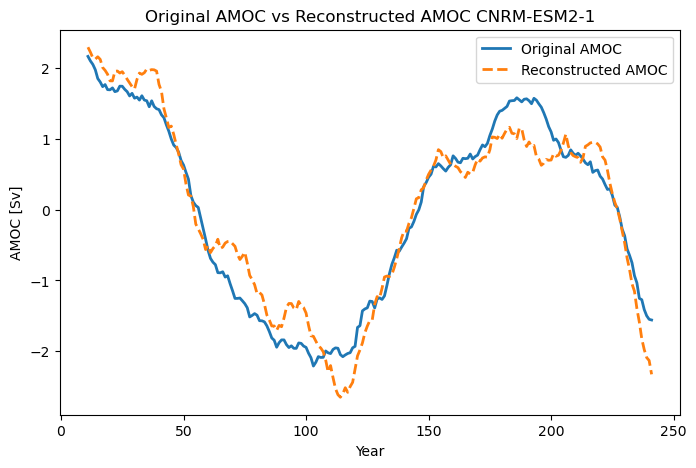

f range: -0.9209 to 0.9730
AMOC range: -2.2094 to 2.1638
Reconstructed AMOC range: -2.6496 to 2.2933
CanESM5-CanOE
Saved to ../data/SST_AMOC_saved_regressions/CanESM5-CanOE_231yrs.nc


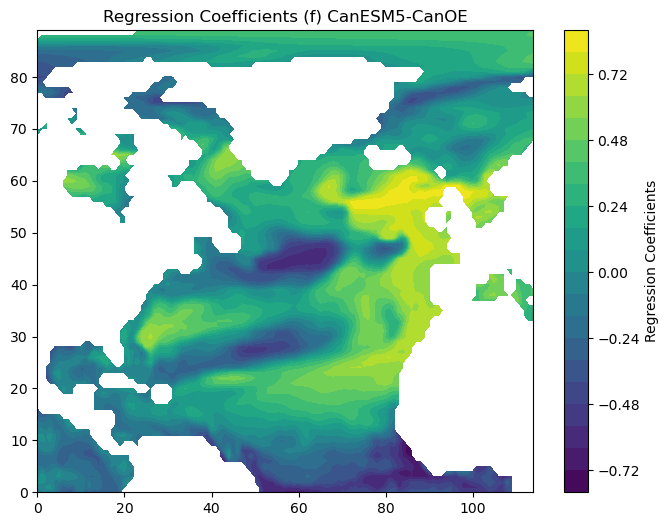

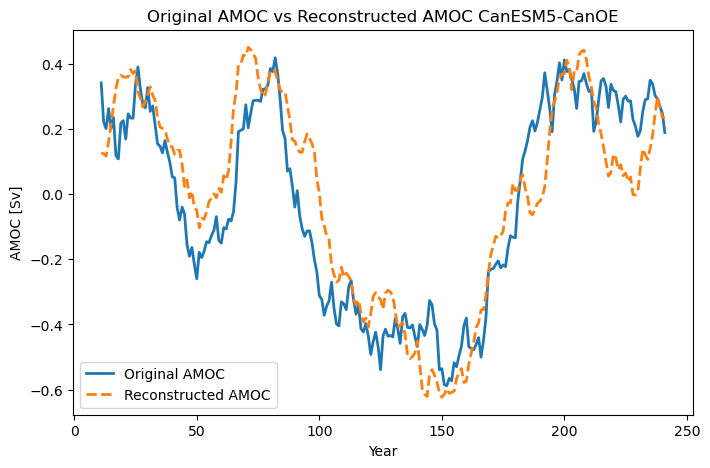

f range: -0.7794 to 0.8553
AMOC range: -0.5882 to 0.4186
Reconstructed AMOC range: -0.6234 to 0.4509
CanESM5
Saved to ../data/SST_AMOC_saved_regressions/CanESM5_231yrs.nc


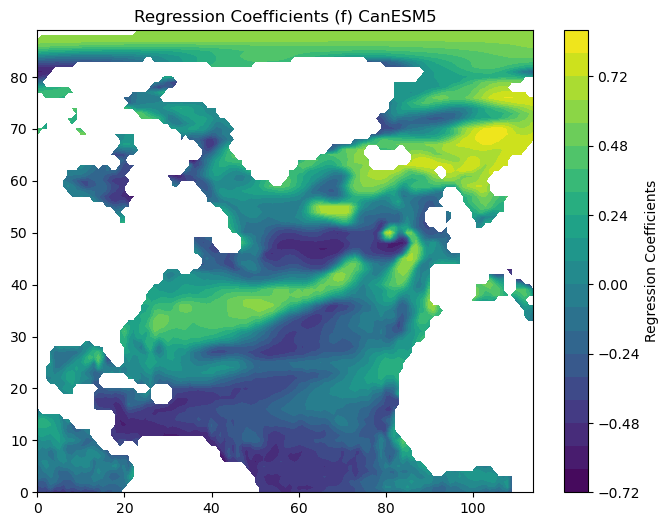

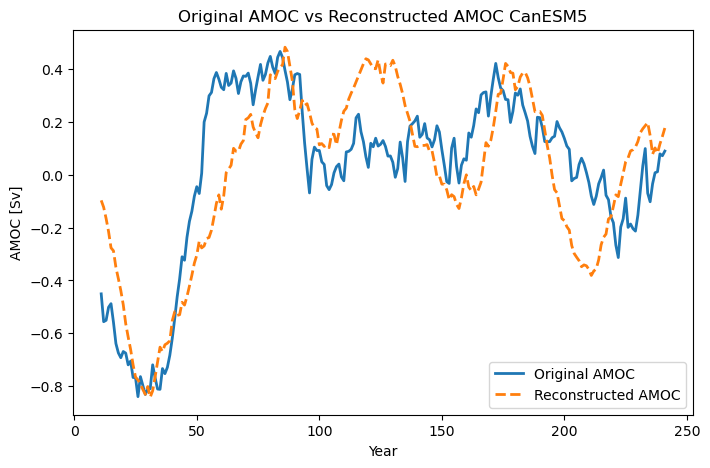

f range: -0.6461 to 0.8740
AMOC range: -0.8399 to 0.4672
Reconstructed AMOC range: -0.8421 to 0.4832
GFDL-CM4
Saved to ../data/SST_AMOC_saved_regressions/GFDL-CM4_231yrs.nc


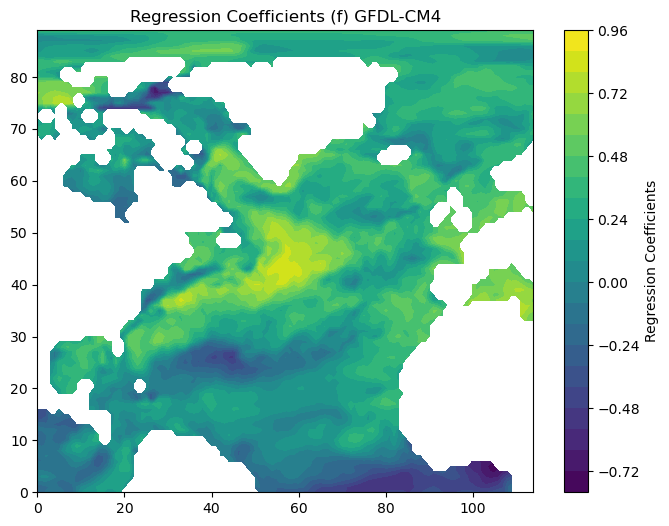

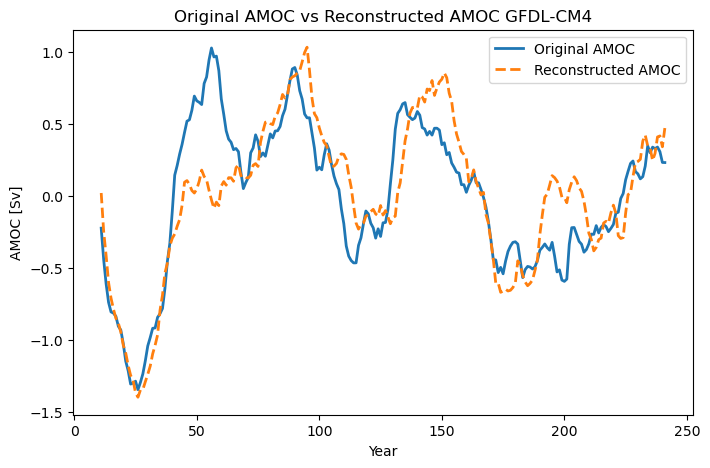

f range: -0.7618 to 0.8801
AMOC range: -1.3469 to 1.0301
Reconstructed AMOC range: -1.3996 to 1.0354
GFDL-ESM4
Saved to ../data/SST_AMOC_saved_regressions/GFDL-ESM4_231yrs.nc


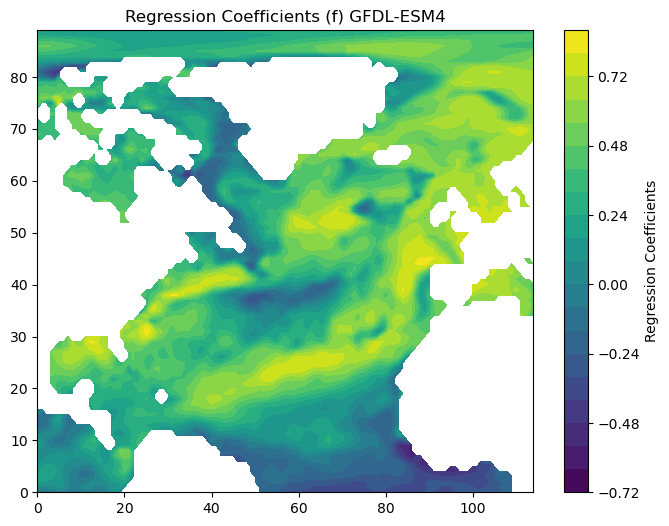

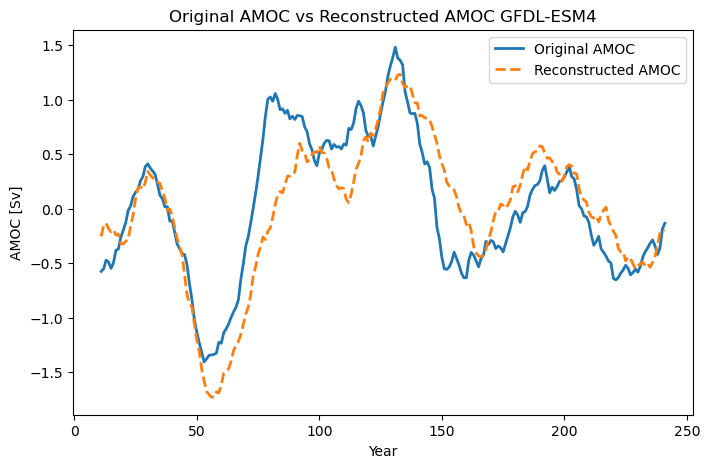

f range: -0.6472 to 0.8288
AMOC range: -1.4040 to 1.4799
Reconstructed AMOC range: -1.7283 to 1.2324
GISS-E2-1-G
Saved to ../data/SST_AMOC_saved_regressions/GISS-E2-1-G_231yrs.nc


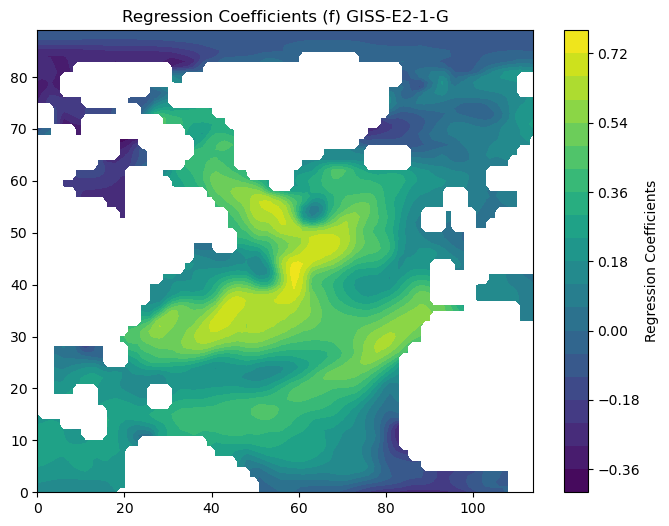

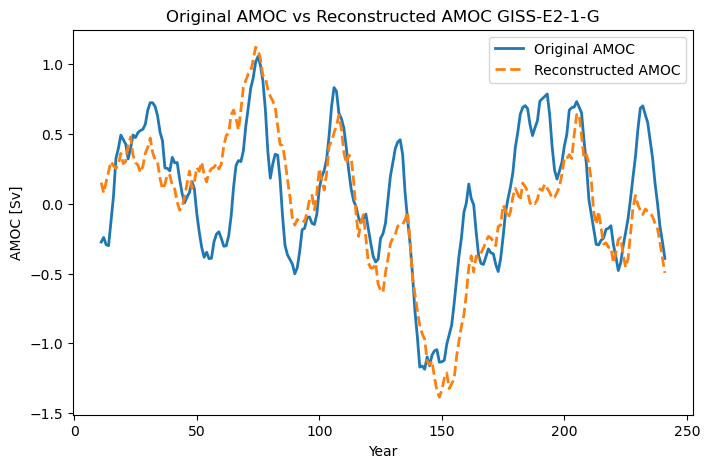

f range: -0.3929 to 0.7397
AMOC range: -1.1854 to 1.0548
Reconstructed AMOC range: -1.3858 to 1.1205
HadGEM3-GC31-LL
Saved to ../data/SST_AMOC_saved_regressions/HadGEM3-GC31-LL_231yrs.nc


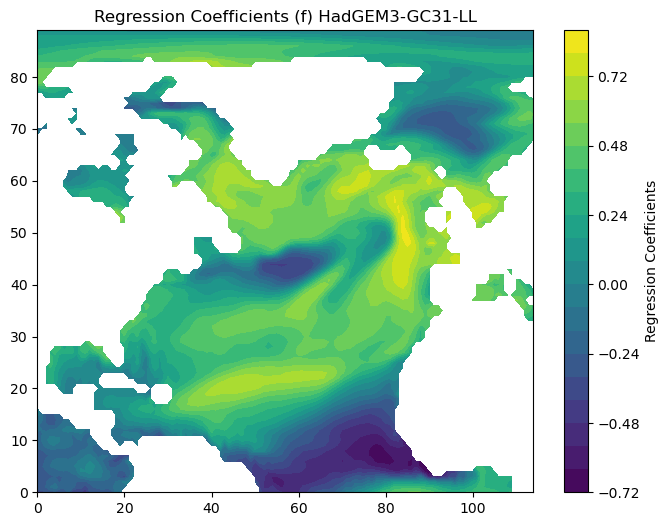

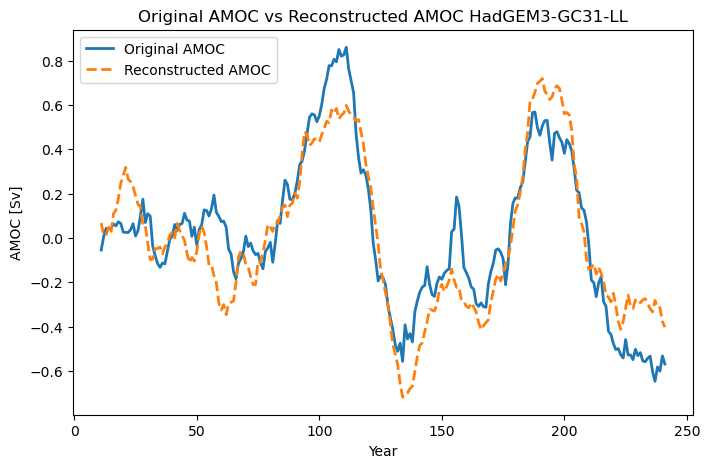

f range: -0.6862 to 0.8293
AMOC range: -0.6461 to 0.8602
Reconstructed AMOC range: -0.7178 to 0.7192
HadGEM3-GC31-MM
Saved to ../data/SST_AMOC_saved_regressions/HadGEM3-GC31-MM_231yrs.nc


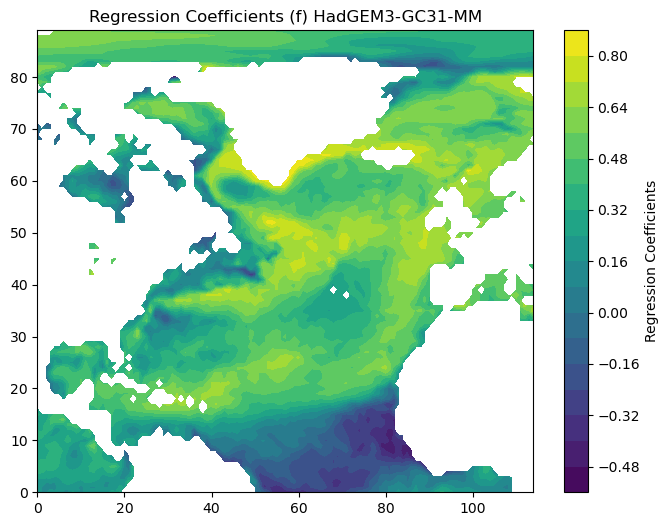

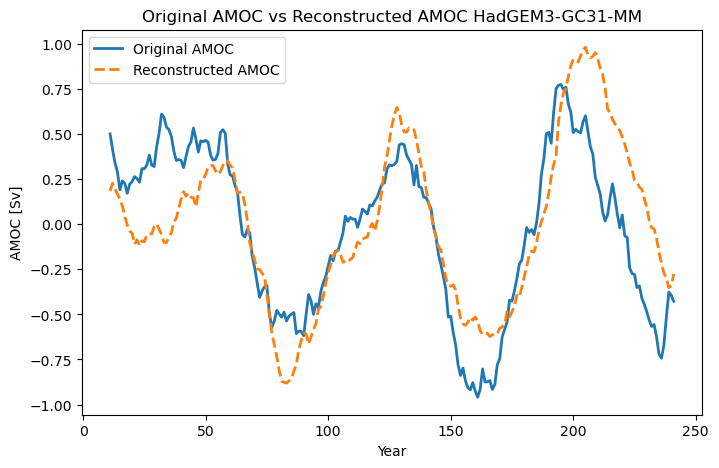

f range: -0.4995 to 0.8459
AMOC range: -0.9595 to 0.7759
Reconstructed AMOC range: -0.8815 to 0.9826
IPSL-CM6A-LR
Saved to ../data/SST_AMOC_saved_regressions/IPSL-CM6A-LR_231yrs.nc


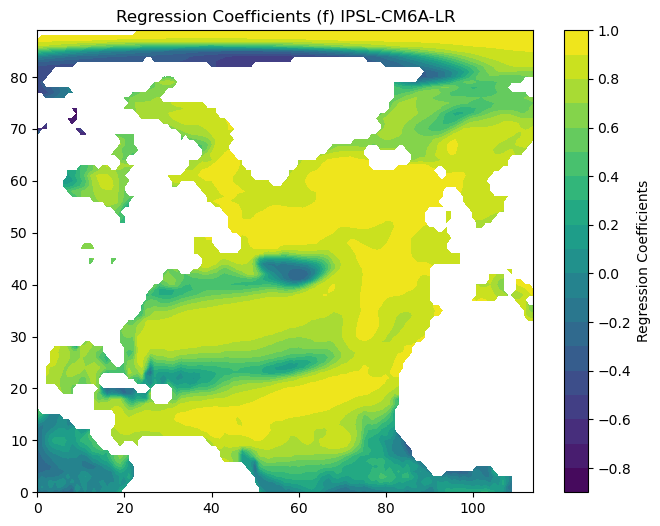

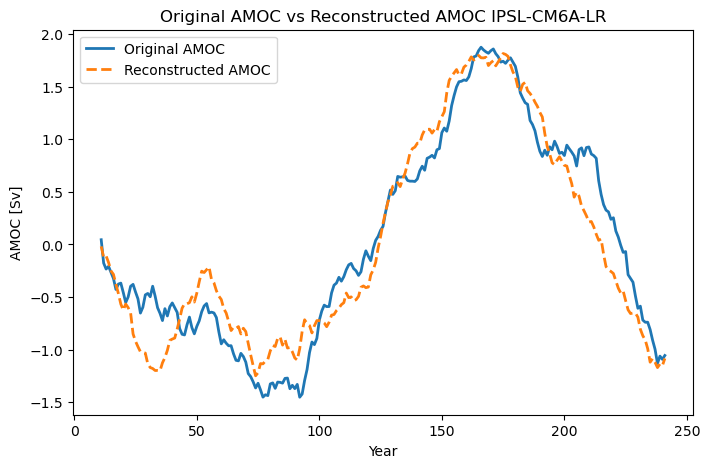

f range: -0.8419 to 0.9612
AMOC range: -1.4533 to 1.8753
Reconstructed AMOC range: -1.2495 to 1.8155
MIROC6
Saved to ../data/SST_AMOC_saved_regressions/MIROC6_231yrs.nc


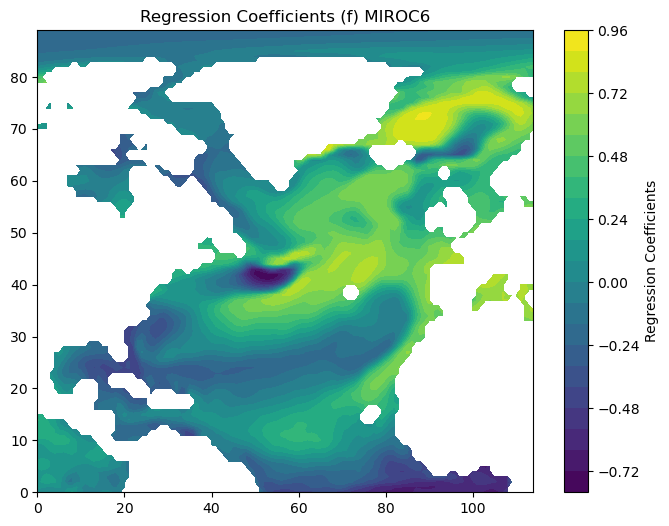

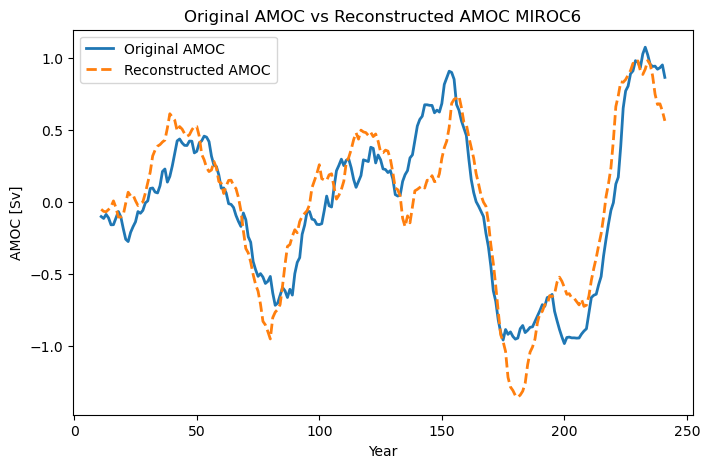

f range: -0.7862 to 0.8877
AMOC range: -0.9830 to 1.0762
Reconstructed AMOC range: -1.3556 to 0.9835
MPI-ESM1-2-HR
Saved to ../data/SST_AMOC_saved_regressions/MPI-ESM1-2-HR_231yrs.nc


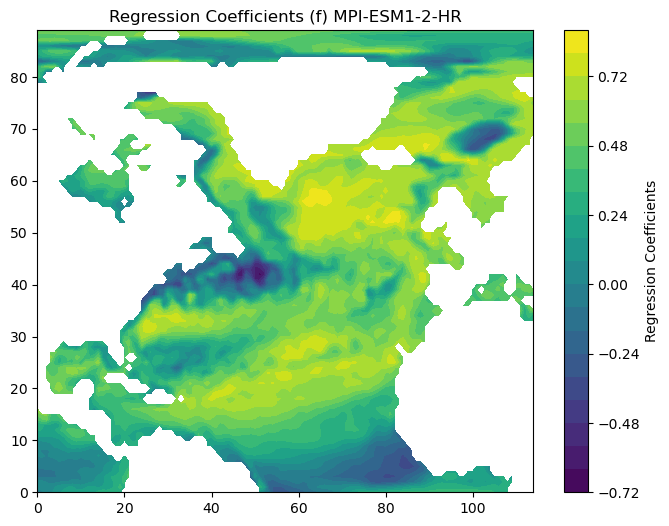

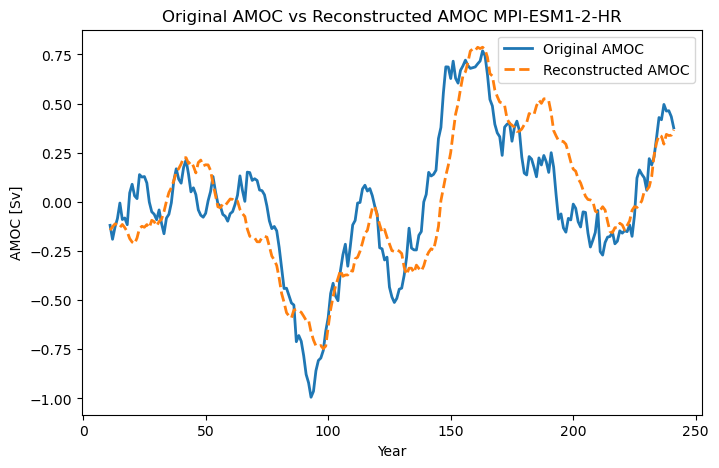

f range: -0.6801 to 0.8490
AMOC range: -0.9936 to 0.7681
Reconstructed AMOC range: -0.7466 to 0.7866
MPI-ESM1-2-LR
Saved to ../data/SST_AMOC_saved_regressions/MPI-ESM1-2-LR_231yrs.nc


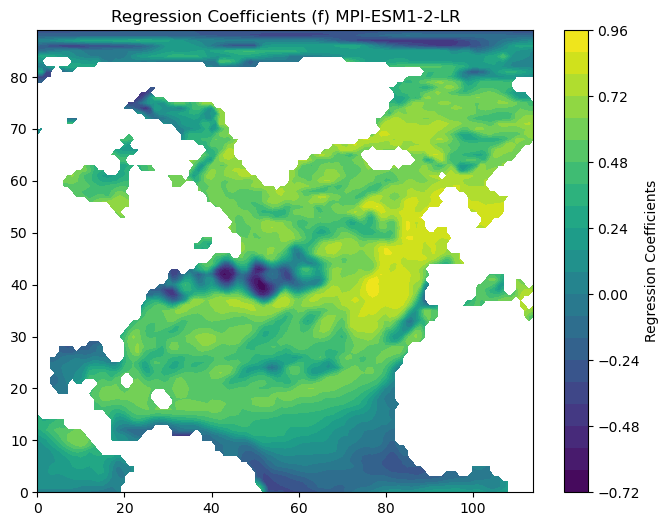

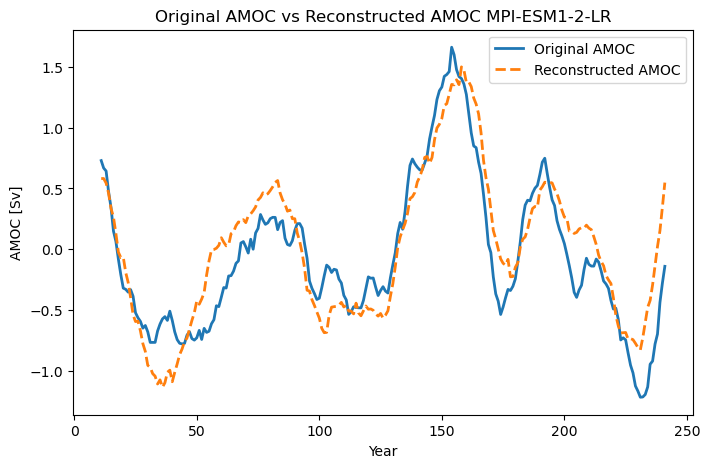

f range: -0.7139 to 0.9047
AMOC range: -1.2134 to 1.6589
Reconstructed AMOC range: -1.1316 to 1.4977
MRI-ESM2-0
Saved to ../data/SST_AMOC_saved_regressions/MRI-ESM2-0_231yrs.nc


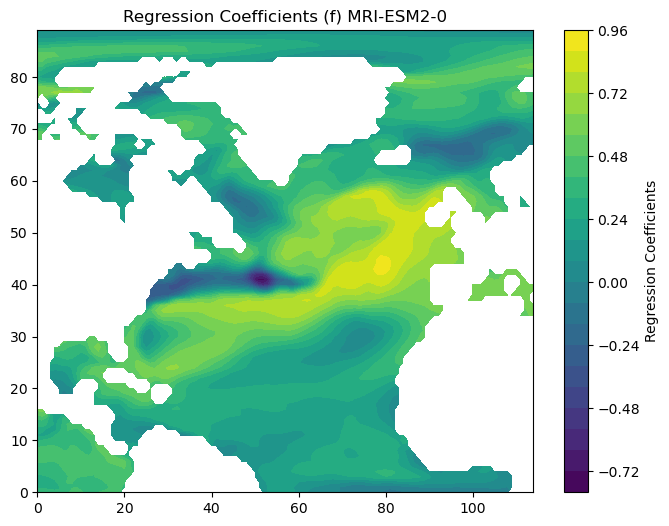

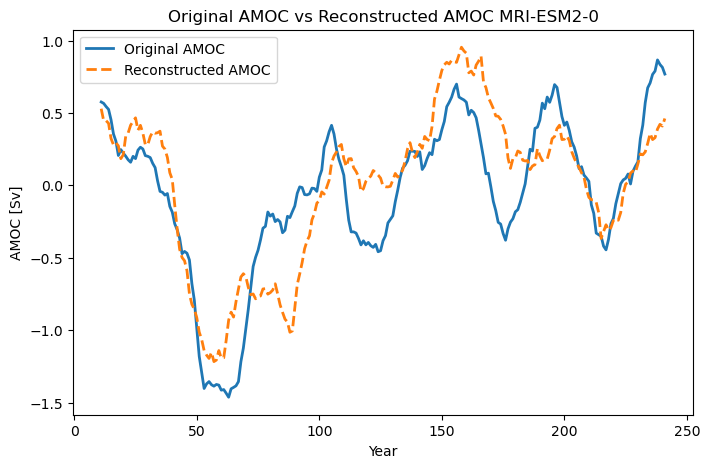

f range: -0.7647 to 0.8931
AMOC range: -1.4634 to 0.8666
Reconstructed AMOC range: -1.2173 to 0.9543
NorESM2-LM
Saved to ../data/SST_AMOC_saved_regressions/NorESM2-LM_231yrs.nc


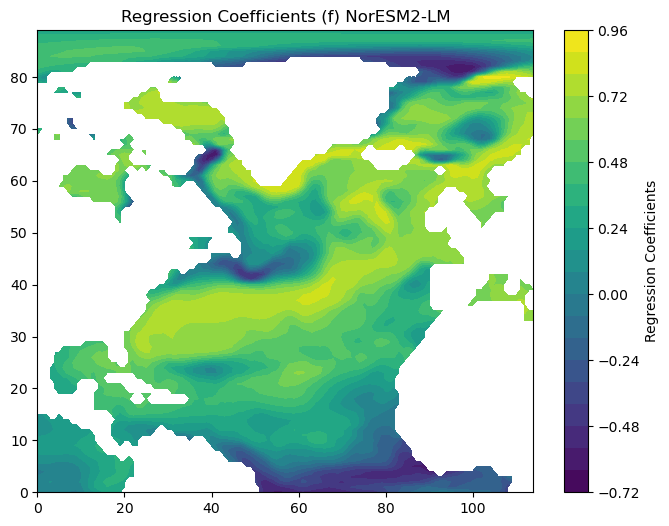

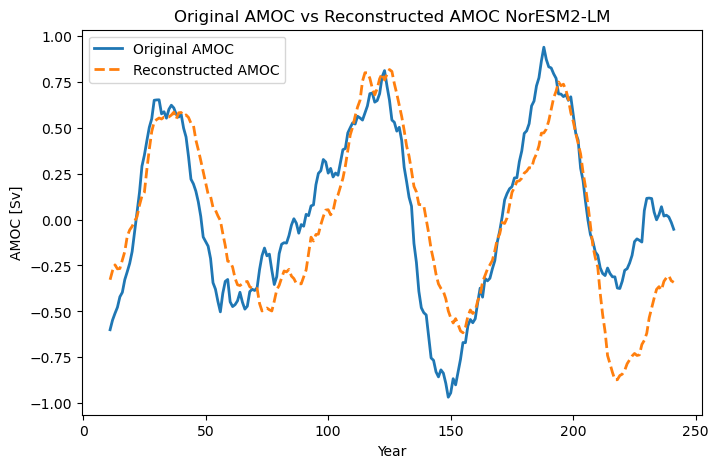

f range: -0.6459 to 0.9302
AMOC range: -0.9672 to 0.9382
Reconstructed AMOC range: -0.8722 to 0.8168
NorESM2-MM
Saved to ../data/SST_AMOC_saved_regressions/NorESM2-MM_231yrs.nc


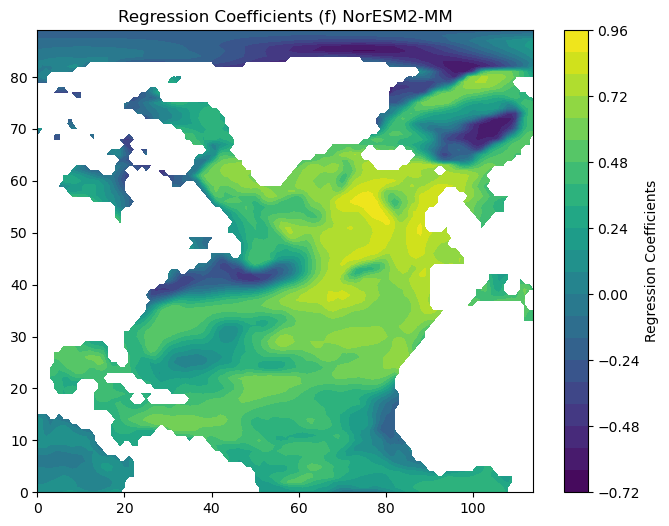

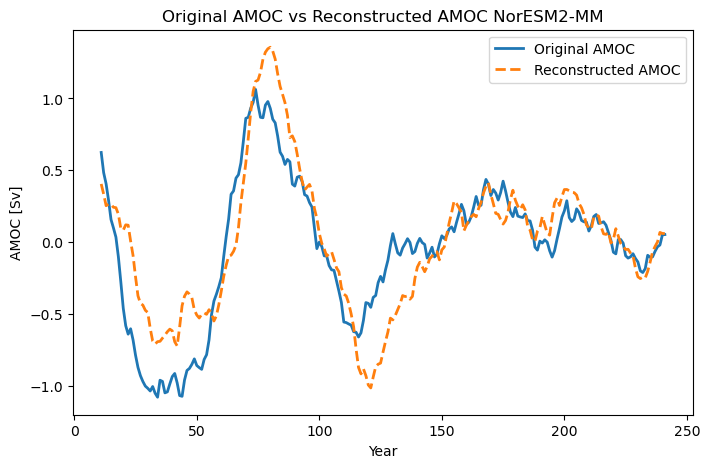

f range: -0.6548 to 0.9340
AMOC range: -1.0787 to 1.0630
Reconstructed AMOC range: -1.0141 to 1.3566
UKESM1-0-LL
Saved to ../data/SST_AMOC_saved_regressions/UKESM1-0-LL_231yrs.nc


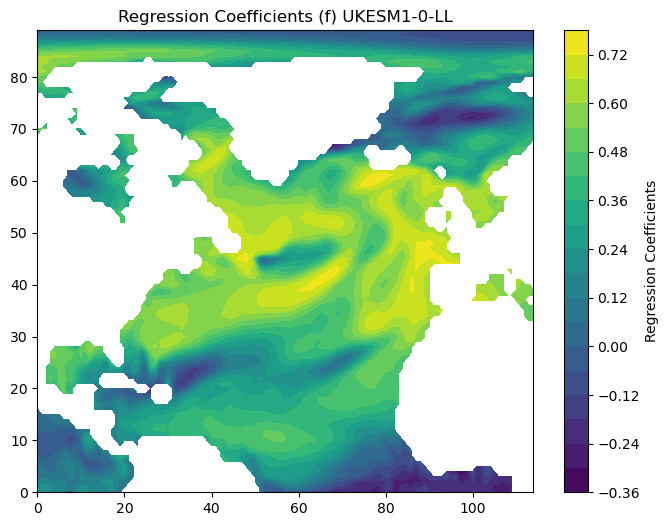

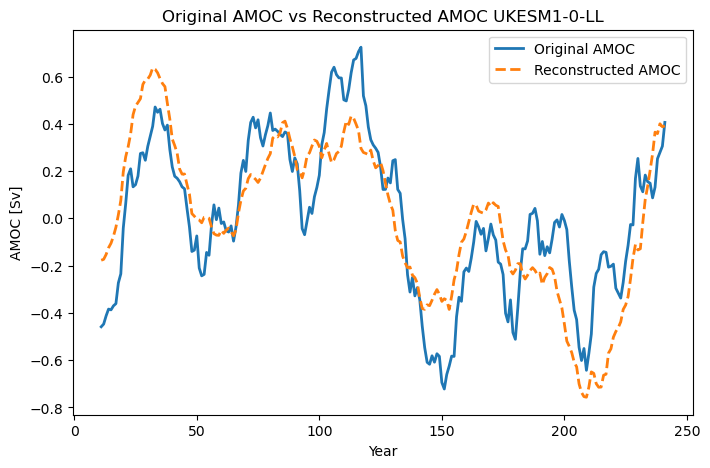

f range: -0.3588 to 0.7522
AMOC range: -0.7220 to 0.7242
Reconstructed AMOC range: -0.7568 to 0.6368


In [10]:
for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1, len(amoc_smoothed['year'].values)+1), dims = 'year')

        amoc = amoc_smoothed

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]
    
        # Prepare and normalize data    
        sst_normalized = prepare_and_normalize_sst(sst)
        amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)
    
        # Train regression and reconstruct AMOC
        f, amoc_reconstructed = train_regression_and_reconstruct(sst_normalized, amoc_normalized, amoc_std)

        years = sst.year.values
        save_regression_map_sst_amoc_to_file(f, ny, nx, years, sst_smoothed, sst_normalized, amoc_normalized, amoc_std, amoc_reconstructed, model, PATH_saved_regressions, smoothing_period = running_mean_window)
    
        # Plot regression coefficients
        plot_regression_coefficients(f, ny, nx, f"Regression Coefficients (f) " + model, model_names)
    
        # Plot AMOC comparison
        plot_amoc_comparison(amoc, amoc_reconstructed, years, 
                             f"Original AMOC vs Reconstructed AMOC " + model, smoothing_period = running_mean_window)
    
        # Debugging information
        print(f"f range: {np.min(f):.4f} to {np.max(f):.4f}")
        print(f"AMOC range: {np.min(amoc):.4f} to {np.max(amoc):.4f}")
        print(f"Reconstructed AMOC range: {np.min(amoc_reconstructed):.4f} to {np.max(amoc_reconstructed):.4f}")


# Compare original AMOC vs. various reconstructions:
- Using this model's own regression pattern
- Using other models' regression patterns
- Using the full multi-model regression pattern: (1) subsampled, and (2) non-subsampled

# Step 1: sanity check 
plotting timeseries of reconstructions vs original AMOC 

ACCESS-CM2
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


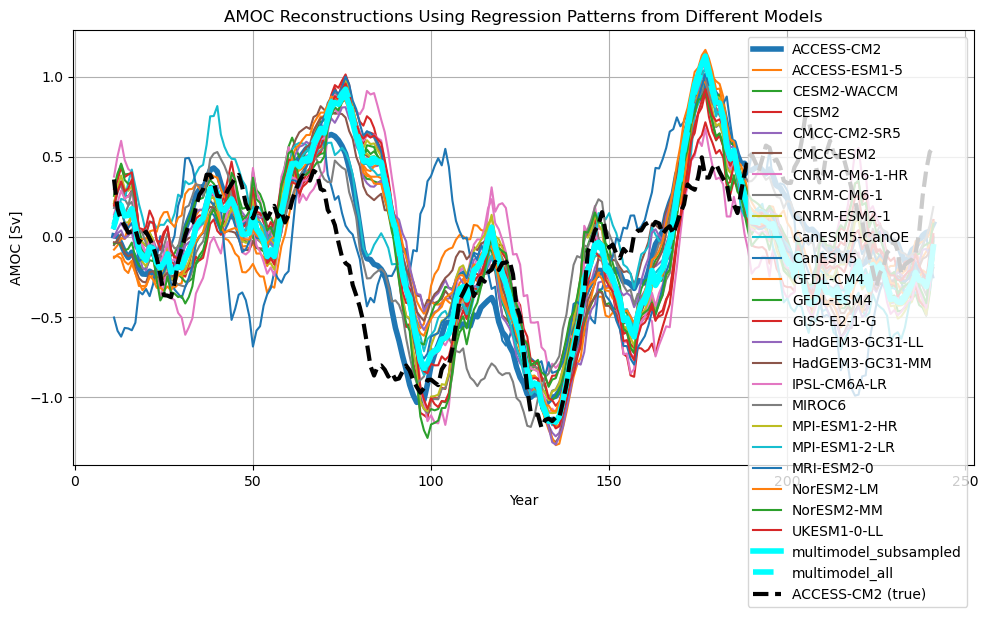

ACCESS-ESM1-5
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


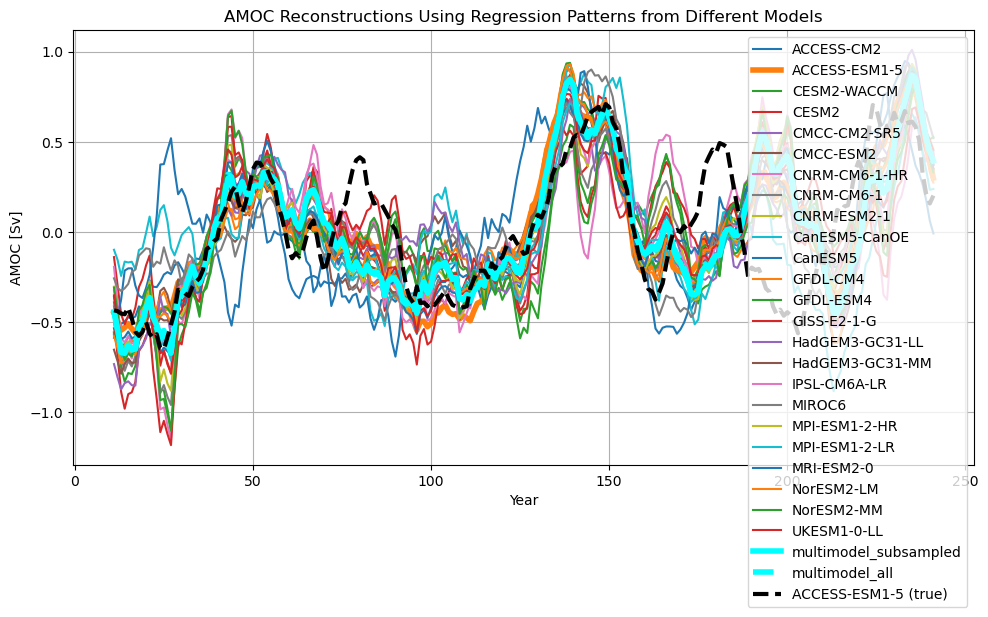

CESM2-WACCM
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


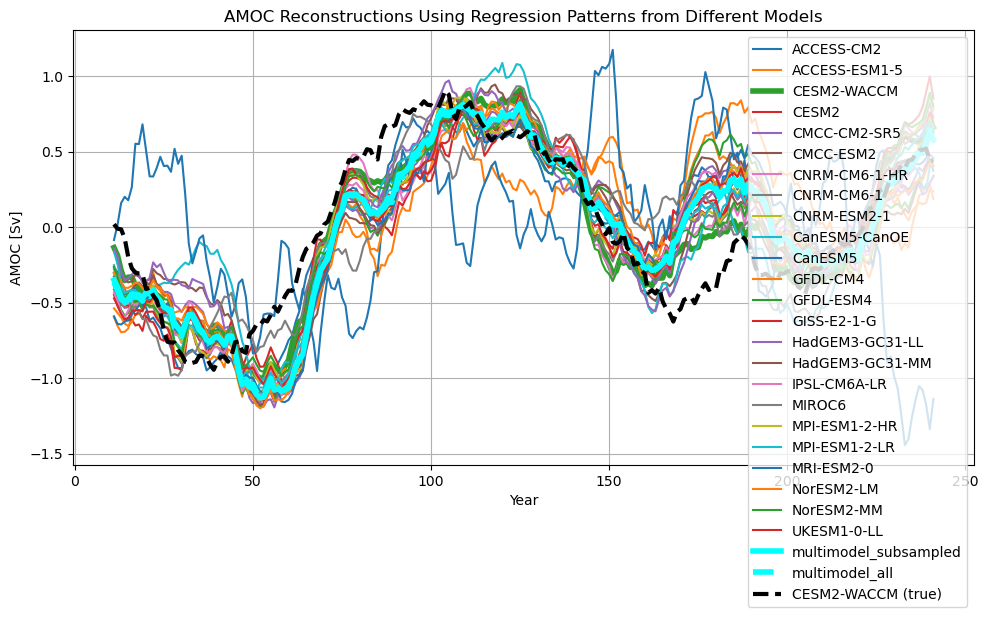

CESM2
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5
CMCC-ESM2
CNRM-CM6-1-HR
CNRM-CM6-1
CNRM-ESM2-1
CanESM5-CanOE
CanESM5
GFDL-CM4
GFDL-ESM4
GISS-E2-1-G
HadGEM3-GC31-LL
HadGEM3-GC31-MM
IPSL-CM6A-LR
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NorESM2-LM
NorESM2-MM
UKESM1-0-LL


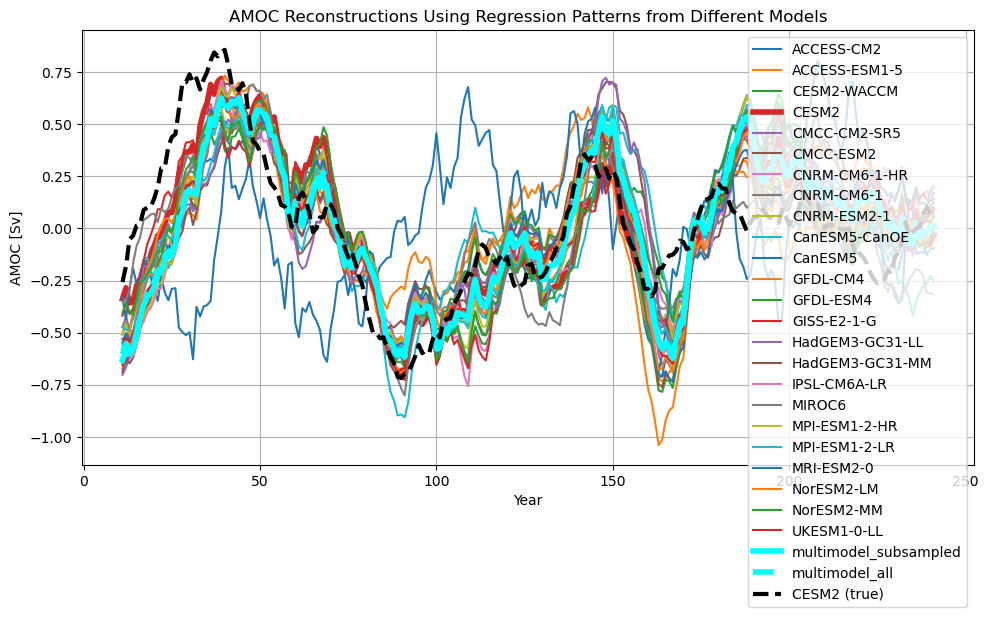

CMCC-CM2-SR5
ACCESS-CM2
ACCESS-ESM1-5
CESM2-WACCM
CESM2
CMCC-CM2-SR5


OSError: [Errno -101] NetCDF: HDF error: '/Users/damrhein/Documents/2024-2025/mezcal/data/SST_AMOC_saved_regressions/CMCC-CM2-SR5_231yrs.nc'

In [11]:
for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        sst_normalized = prepare_and_normalize_sst(sst)

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1), dims = 'year')

        amoc = amoc_smoothed

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]
    
        # Prepare and normalize data    
        sst_normalized = prepare_and_normalize_sst(sst)
        amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)

        amoc_recon_with_regressions_from_different_models = xr.Dataset()
        
        for imr, model_regr in enumerate(model_names):
            print(model_regr)
            regression_pattern = xr.open_dataset(PATH_saved_regressions + model_regr + '_231yrs.nc').fr.fillna(0).values.flatten()

            amoc_reconstructed = sst_normalized @ regression_pattern
            amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed) + amoc_mean

            amoc_recon_with_regressions_from_different_models[model_regr] = xr.DataArray(amoc_reconstructed,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)

        
        # Adding reconstruction computed using regression pattern from multi-model regression (subsampled)

        amoc_reconstructed_mm_subsampled = sst_normalized @ f_mm_subsampled
        amoc_reconstructed_mm_subsampled = amoc_reconstructed_mm_subsampled * amoc_std / np.std(amoc_reconstructed_mm_subsampled) + amoc_mean

        amoc_recon_with_regressions_from_different_models['multimodel_subsampled'] = xr.DataArray(amoc_reconstructed_mm_subsampled,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)


        # Adding reconstruction computed using regression pattern from multi-model regression (not subsampled - i.e. all years in all models)
        amoc_reconstructed_mm_all = sst_normalized @ f_mm_all
        amoc_reconstructed_mm_all = amoc_reconstructed_mm_all * amoc_std / np.std(amoc_reconstructed_mm_all) + amoc_mean

        amoc_recon_with_regressions_from_different_models['multimodel_all'] = xr.DataArray(amoc_reconstructed_mm_all,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)


        
        plt.figure(figsize=(10, 6))

        for model_regr in amoc_recon_with_regressions_from_different_models.data_vars:
            if model_regr == model:
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr, linewidth = 4)
            elif model_regr == 'multimodel_all':
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr, linewidth = 4, c = 'cyan', linestyle = '--')
            elif model_regr == 'multimodel_subsampled':
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr, linewidth = 4, c = 'cyan')
            else:
                da = amoc_recon_with_regressions_from_different_models[model_regr]
                plt.plot(da["year"], da, label=model_regr)

        plt.plot(amoc_smoothed['year'], amoc_smoothed, label = model + ' (true)', color='black', linewidth=3, linestyle='--')
        
                
        
        plt.title("AMOC Reconstructions Using Regression Patterns from Different Models")
        plt.xlabel("Year")
        plt.ylabel("AMOC [Sv]")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Step 2: calculating RMSE and writing them to arrays 

In [ ]:
rmse_matrix = {}
for i, model in enumerate(model_names):
    filename_amoc = PATH_AMOC + 'amoc_' + scenario + '_' + amoc_institution_names[i] + '_' + model + '_' + ens_members_appendices[i] + '.nc'
    filename_sst = PATH_SST + 'tos_Omon_' + model + '_' + scenario + '_' + ens_members_appendices[i] + '.nc'
    if os.path.exists(filename_amoc) and os.path.exists(filename_sst):

        #print(model)
        
        sst_time_series = xr.open_dataset(filename_sst)['tos'].sel(lat = slice(lat_min, lat_max), lon = slice(lon_min, lon_max))
        sst_time_series['year'] = xr.DataArray(np.arange(1, len(sst_time_series['year'].values)+1), dims = 'year')
        sst_mean = sst_time_series.mean('year')
        sst_smoothed = (sst_time_series - sst_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')

        sst = sst_smoothed

        sst_normalized = prepare_and_normalize_sst(sst)

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]

        if model == 'IPSL-CM6A-LR':
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)), x = 0)
        else:
            amoc_time_series = xr.open_dataset(filename_amoc)['amoc'].isel(year = slice(0, len(sst_time_series)))
            
        amoc_mean = amoc_time_series.mean('year')
        amoc_smoothed = (amoc_time_series - amoc_mean).rolling(year=running_mean_window, center=True).mean().dropna(dim='year', how='all')
        amoc_smoothed['year'] = xr.DataArray(np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1), dims = 'year')

        amoc = amoc_smoothed

        # Get spatial grid dimensions for the North Atlantic region
        ny = sst.mean('year').shape[0]
        nx = sst.mean('year').shape[1]
    
        # Prepare and normalize data    
        sst_normalized = prepare_and_normalize_sst(sst)
        amoc, amoc_normalized, amoc_mean, amoc_std = prepare_and_normalize_amoc(amoc)

        amoc_recon_with_regressions_from_different_models = xr.Dataset()
        
        for imr, model_regr in enumerate(model_names):
            #print(model_regr)
            regression_pattern = xr.open_dataset(PATH_saved_regressions + model_regr + '_231yrs.nc').fr.fillna(0).values.flatten()

            amoc_reconstructed = sst_normalized @ regression_pattern
            amoc_reconstructed = amoc_reconstructed * amoc_std / np.std(amoc_reconstructed) + amoc_mean

            amoc_recon_with_regressions_from_different_models[model_regr] = xr.DataArray(amoc_reconstructed,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)

        
        # Adding reconstruction computed using regression pattern from multi-model regression (subsampled)

        amoc_reconstructed_mm_subsampled = sst_normalized @ f_mm_subsampled
        amoc_reconstructed_mm_subsampled = amoc_reconstructed_mm_subsampled * amoc_std / np.std(amoc_reconstructed_mm_subsampled) + amoc_mean

        amoc_recon_with_regressions_from_different_models['multimodel_subsampled'] = xr.DataArray(amoc_reconstructed_mm_subsampled,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)


        # Adding reconstruction computed using regression pattern from multi-model regression (not subsampled - i.e. all years in all models)
        amoc_reconstructed_mm_all = sst_normalized @ f_mm_all
        amoc_reconstructed_mm_all = amoc_reconstructed_mm_all * amoc_std / np.std(amoc_reconstructed_mm_all) + amoc_mean

        amoc_recon_with_regressions_from_different_models['multimodel_all'] = xr.DataArray(amoc_reconstructed_mm_all,
                                                                                         dims=["year"],
                                                                                         coords={"year": np.arange(1 + running_mean_window/2, 251 - running_mean_window/2 + 1)},
                                                                                         name=model_regr)


        
        # Compute RMSE between reconstructions and true AMOC
        rmse_dict = {}
        
        for model_regr in amoc_recon_with_regressions_from_different_models.data_vars:
            recon = amoc_recon_with_regressions_from_different_models[model_regr].values
            truth = amoc_smoothed.values
            rmse = np.sqrt(np.mean((recon - truth) ** 2))
            rmse_dict[model_regr] = rmse
        
        # Store per target model
        rmse_matrix[model] = rmse_dict

print('RMSE matrix created!')

In [ ]:
rmse_df = pd.DataFrame(rmse_matrix).T  # rows: target models, columns: source regression models
rmse_df = rmse_df[model_names + ['multimodel_subsampled', 'multimodel_all']]  # consistent column order

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rmse_df.index))  # positions for each target model

colors = sns.color_palette("tab20b", n_colors=len(model_names))
# colors = sns.color_palette("hsv", n_colors=len(model_names))



# # Plot each regression pattern used (each column)
# for i, source in enumerate(model_names):
#     for j, target in enumerate(rmse_df.index):
#         ax.scatter(j, rmse_df.loc[target, source], color=colors[i], s=40, label=source if j == 0 else "")



for i, source in enumerate(model_names):
    for j, target in enumerate(rmse_df.index):
        rmse_val = rmse_df.loc[target, source]
        if target == source:
            # Self-model: special marker (e.g. diamond or X)
            ax.scatter(j, rmse_val, 
                       color=colors[i], marker='D', s=60, 
                       label=source if j == 0 else "")
        else:
            # Regular dot
            ax.scatter(j, rmse_val, 
                       color=colors[i], marker='o', s=40, 
                       label=source if j == 0 else "")

# Add black/gray dots for multi-model reconstructions
for j, target in enumerate(rmse_df.index):
    # ax.scatter(j, rmse_df.loc[target, 'multimodel_all'], color='black', marker='*', s=60, label='Multi-model' if j == 0 else "")
    ax.scatter(j, rmse_df.loc[target, 'multimodel_subsampled'], color='black', marker='X', s=60, label='Multi-model (subsampled)' if j == 0 else "")


ax.set_xticks(x)
ax.set_xticklabels(rmse_df.index, rotation=90)
ax.set_ylabel("AMOC RMSE [Sv]")
ax.set_title("AMOC Reconstruction Error (RMSE) using Different Regression Patterns")
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
# plt.tight_layout()
# plt.grid(True)


# Collect current legend handles and labels
handles, labels = ax.get_legend_handles_labels()

# Build ordered dict to remove duplicates (preserves first occurrence)
from collections import OrderedDict
unique = OrderedDict()

for h, l in zip(handles, labels):
    if l not in unique and l != model_names[0]:  # exclude self-model entry for first model
        unique[l] = h

# Add 'Self-model' legend entry manually (optional, clean label)
if 'Self-model' in labels:
    self_index = labels.index('Self-model')
    unique['Self-model'] = handles[self_index]

# Set final legend
ax.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)


# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1, frameon=False)
plt.tight_layout()
plt.grid(True, alpha=0.3)


plt.show()